## Librerias

In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from torchvision import datasets, transforms
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
device = torch.device('cpu')

## 1. Dataset


In [2]:
train_raw = datasets.MNIST(root='data', train=True, download=True)
test_raw = datasets.MNIST(root='data', train=False, download=True)

X_train_full = train_raw.data.numpy()
y_train_full = train_raw.targets.numpy()
X_test = test_raw.data.numpy()
y_test = test_raw.targets.numpy()

print('Forma de X_train_full:', X_train_full.shape)
print('Forma de X_test:', X_test.shape)


  0%|          | 0.00/9.91M [00:00<?, ?B/s]


  1%|          | 98.3k/9.91M [00:00<00:18, 536kB/s]


  4%|▍         | 426k/9.91M [00:00<00:07, 1.23MB/s]


 17%|█▋        | 1.70M/9.91M [00:00<00:01, 4.79MB/s]


 35%|███▌      | 3.47M/9.91M [00:00<00:00, 7.15MB/s]

...


 44%|████▎     | 721k/1.65M [00:00<00:00, 2.45MB/s]


100%|██████████| 1.65M/1.65M [00:00<00:00, 3.81MB/s]


  0%|          | 0.00/4.54k [00:00<?, ?B/s]


100%|██████████| 4.54k/4.54k [00:00<00:00, 11.2MB/s]

Forma de X_train_full: (60000, 28, 28)
Forma de X_test: (10000, 28, 28)


## 2. Exploracion y preparacion de los datos

### 2.1 Cantidad de observaciones y clases, balance

In [3]:
n_train, n_test = X_train_full.shape[0], X_test.shape[0]
n_classes = len(np.unique(y_train_full))

print(f"Observaciones en entrenamiento: {n_train}")
print(f"Observaciones en prueba: {n_test}")
print(f"Numero de clases: {n_classes}")

clases, conteos = np.unique(y_train_full, return_counts=True)
balance_df = pd.DataFrame({'digito': clases, 'conteo': conteos})
balance_df['porcentaje'] = (balance_df['conteo'] / n_train * 100).round(2)
balance_df

Observaciones en entrenamiento: 60000
Observaciones en prueba: 10000
Numero de clases: 10


,digito,conteo,porcentaje
0,0,5923,9.87
1,1,6742,11.24
2,2,5958,9.93
3,3,6131,10.22
4,4,5842,9.74
5,5,5421,9.04
6,6,5918,9.86
7,7,6265,10.44
8,8,5851,9.75
9,9,5949,9.92


#### Cuantas observaciones y clases tiene el dataset, estan balanceadas

El dataset tiene 60000 imagenes de entrenamiento y 10000 de prueba, para un total de 70000 observaciones, cada una etiquetada con uno de 10 digitos. Las clases estan practicamente balanceadas: cada digito representa entre 9 y 11 por ciento del total de observaciones de entrenamiento, sin ninguna clase dominante ni minoritaria en un problema de clasificacion de 10 clases.

### 2.2 Dimension de las imagenes y rango de los pixeles

In [4]:
imagen_ejemplo = X_train_full[0]
print('Dimension de cada imagen:', imagen_ejemplo.shape)
print('Tipo de dato:', imagen_ejemplo.dtype)
print('Valor minimo de pixel:', X_train_full.min())
print('Valor maximo de pixel:', X_train_full.max())

Dimension de cada imagen: (28, 28)
Tipo de dato: uint8
Valor minimo de pixel: 0
Valor maximo de pixel: 255


#### Cual es la dimension de cada imagen y que rango de valores tienen los pixeles

Cada imagen es una matriz de 28 por 28 pixeles en escala de grises, es decir un unico canal. Los valores de los pixeles son enteros sin signo de 8 bits, en el rango de 0 a 255, donde 0 representa negro y 255 representa blanco.

### 2.3 Necesidad de normalizar los pixeles

In [5]:
X_train_norm = (X_train_full / 255.0).astype(np.float32)
X_test_norm = (X_test / 255.0).astype(np.float32)

print('Rango tras normalizar:', X_train_norm.min(), '-', X_train_norm.max())

Rango tras normalizar: 0.0 - 1.0


#### Es necesario normalizar los valores de los pixeles

Si es necesario. Los pixeles en el rango de 0 a 255 producen activaciones y gradientes de magnitud muy grande al entrar a la primera capa, lo que hace mas lento e inestable el entrenamiento con descenso de gradiente. Se dividio cada pixel entre 255 para llevarlos al rango de 0 a 1, una normalizacion estandar para imagenes que mantiene la escala comparable entre todos los pixeles y todas las imagenes del dataset, sin necesidad de calcular media y desviacion estandar por separado ya que el rango original es fijo y conocido para todas las imagenes.

### 2.4 Visualizacion de ejemplos

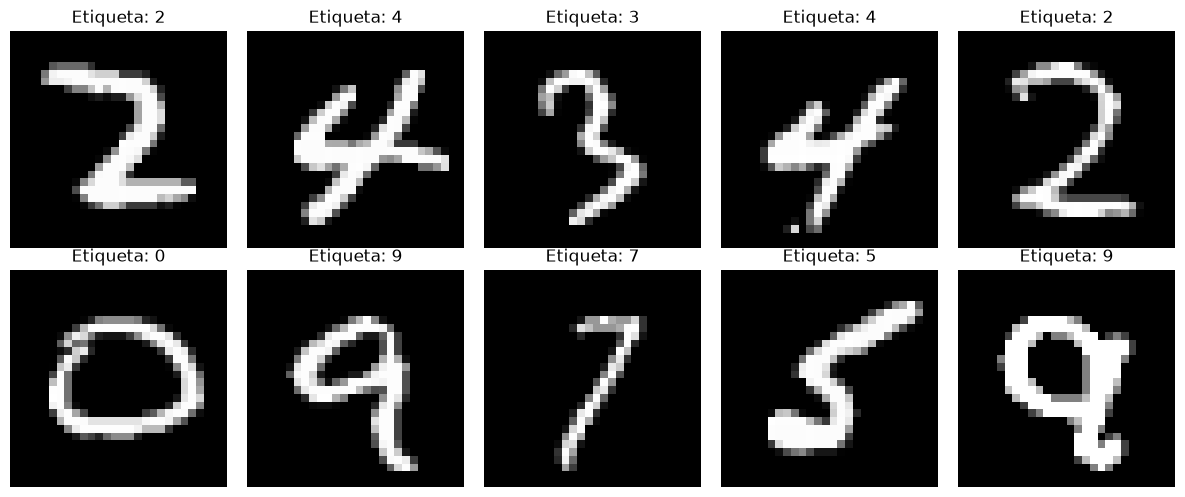

In [6]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
rng = np.random.default_rng(SEED)
idx_muestra = rng.choice(n_train, size=10, replace=False)

for ax, idx in zip(axes.flat, idx_muestra):
    ax.imshow(X_train_full[idx], cmap='gray')
    ax.set_title(f'Etiqueta: {y_train_full[idx]}')
    ax.axis('off')

plt.tight_layout()
plt.show()

### 2.5 Division en entrenamiento y validacion

In [7]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train_norm, y_train_full, test_size=0.2, random_state=SEED, stratify=y_train_full
)

print('Observaciones en train:', X_train.shape[0])
print('Observaciones en validacion:', X_val.shape[0])
print('Observaciones en test:', X_test_norm.shape[0])

Observaciones en train: 48000
Observaciones en validacion: 12000
Observaciones en test: 10000


El conjunto de entrenamiento original de 60000 imagenes se divide en 80 por ciento entrenamiento y 20 por ciento validacion. El conjunto de prueba de 10000 imagenes, provisto por separado por torchvision, no se toca hasta la evaluacion final de los modelos ya seleccionados.

## 3. Investigacion: capas de PyTorch para la CNN

### nn.Conv2d

Aplica una convolucion 2D, deslizando un conjunto de filtros (kernels) sobre la imagen de entrada para producir mapas de caracteristicas. Sus parametros mas relevantes son in_channels y out_channels, el numero de canales de entrada y salida (el numero de filtros aprendidos), kernel_size, el tamanio del filtro, stride, el paso con el que se desliza el filtro, y padding, el relleno agregado a los bordes para controlar la dimension de salida. Cada filtro comparte los mismos pesos en toda la imagen, lo que le permite detectar el mismo patron (bordes, texturas) sin importar donde aparezca.

### nn.MaxPool2d

Reduce la dimension espacial de un mapa de caracteristicas quedandose con el valor maximo dentro de una ventana, definida por kernel_size y stride. Disminuye el costo computacional de las capas siguientes, aporta cierta invarianza a pequenias traslaciones del patron detectado y ayuda a evitar sobreajuste al reducir la cantidad de informacion que pasa a la siguiente capa.

### nn.AvgPool2d

Igual que MaxPool2d pero en vez de quedarse con el valor maximo de la ventana calcula el promedio. Suaviza la representacion en vez de quedarse con la activacion mas fuerte, por lo que preserva mejor informacion de fondo pero es menos sensible a la presencia de un patron muy marcado dentro de la ventana.

### nn.BatchNorm2d

Normaliza las activaciones de cada canal a lo largo del batch (media 0, varianza 1) y luego aplica una escala y un desplazamiento aprendibles, definidos por num_features, el numero de canales de entrada. Estabiliza y acelera el entrenamiento al mantener las activaciones en un rango consistente entre capas, y en la practica tambien actua como un regularizador leve.

### nn.Flatten

Convierte un tensor multidimensional, por ejemplo el mapa de caracteristicas de salida de las capas convolucionales con forma canales por alto por ancho, en un vector unidimensional por observacion. Es el puente necesario para pasar de las capas convolucionales, que trabajan con tensores 2D, a las capas totalmente conectadas (nn.Linear), que esperan un vector de entrada.

### nn.CrossEntropyLoss

Funcion de perdida para clasificacion multiclase. Combina internamente un softmax sobre los logits de salida con la perdida de log-verosimilitud negativa, por lo que la red no debe aplicar softmax en su ultima capa. Espera como entrada los logits sin normalizar, con forma numero de observaciones por numero de clases, y como objetivo el indice entero de la clase correcta.

### Tensores en PyTorch

Un tensor es la estructura de datos basica de PyTorch, un arreglo multidimensional similar a un ndarray de numpy pero con soporte nativo para ejecutarse en GPU y para el calculo automatico de gradientes (autograd). Todas las entradas, pesos, activaciones y salidas de una red en PyTorch son tensores, y cada operacion que se aplica sobre ellos queda registrada en un grafo computacional que permite calcular las derivadas necesarias para el descenso de gradiente durante el entrenamiento.

### Campo receptivo (receptive field)

Es la region de la imagen de entrada que influye en el valor de una unidad especifica de un mapa de caracteristicas en una capa dada. En la primera capa convolucional el campo receptivo es simplemente el tamanio del kernel, pero al apilar mas capas convolucionales o de pooling el campo receptivo efectivo crece, permitiendo que unidades de capas mas profundas respondan a patrones que abarcan una porcion mucho mayor, o incluso toda, la imagen original.

### Por que una CNN requiere menos parametros que un MLP equivalente

En un MLP, la primera capa totalmente conectada necesita un peso distinto por cada pixel de entrada y por cada neurona de esa capa, sin importar en que posicion de la imagen este el pixel. En una CNN, cada filtro convolucional comparte el mismo conjunto pequenio de pesos (el kernel) en todas las posiciones de la imagen, por lo que el numero de parametros de una capa convolucional depende del tamanio del kernel y del numero de canales, no del tamanio de la imagen. Esta comparticion de pesos, junto con el pooling que reduce la dimension espacial entre capas, permite que una CNN capture patrones espaciales locales (bordes, curvas, trazos) con muchos menos parametros entrenables que un MLP que tendria que aprender un peso independiente para cada combinacion de pixel de entrada y neurona oculta.

## 4. Construccion y entrenamiento de las arquitecturas

### 4.1 Definicion de los modelos: MLP y CNN

Se define una clase MLP, semejante a la del Laboratorio 1, que recibe la imagen aplanada como vector de 784 valores de entrada y una lista configurable de neuronas por capa oculta, con activacion, dropout y BatchNorm1d opcionales, terminando en una capa lineal de 10 salidas (una por digito). Tambien se define una clase CNN, configurable en el numero de bloques convolucionales, el numero de filtros por bloque, el tipo de pooling (max o average), el uso de BatchNorm2d y el dropout antes de la capa de clasificacion final, que recibe la imagen como tensor 2D de un canal. Ambas clases permiten reutilizar el mismo codigo para todas las iteraciones de la busqueda de hiperparametros, cambiando unicamente el diccionario de configuracion.

In [8]:
class MLP(nn.Module):
    def __init__(self, hidden_layers, activation=nn.ReLU, dropout=0.0, batch_norm=False, n_classes=10):
        super().__init__()
        layers = [nn.Flatten()]
        prev_dim = 28 * 28
        for h in hidden_layers:
            layers.append(nn.Linear(prev_dim, h))
            if batch_norm:
                layers.append(nn.BatchNorm1d(h))
            layers.append(activation())
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            prev_dim = h
        layers.append(nn.Linear(prev_dim, n_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


class CNN(nn.Module):
    def __init__(self, conv_channels, activation=nn.ReLU, pool='max', batch_norm=False,
                 fc_hidden=128, dropout=0.0, n_classes=10):
        super().__init__()
        pool_cls = nn.MaxPool2d if pool == 'max' else nn.AvgPool2d

        conv_layers = []
        in_ch = 1
        spatial = 28
        for out_ch in conv_channels:
            conv_layers.append(nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1))
            if batch_norm:
                conv_layers.append(nn.BatchNorm2d(out_ch))
            conv_layers.append(activation())
            conv_layers.append(pool_cls(2))
            in_ch = out_ch
            spatial = spatial // 2
        self.conv = nn.Sequential(*conv_layers)

        fc_layers = [nn.Flatten(), nn.Linear(in_ch * spatial * spatial, fc_hidden), activation()]
        if dropout > 0:
            fc_layers.append(nn.Dropout(dropout))
        fc_layers.append(nn.Linear(fc_hidden, n_classes))
        self.fc = nn.Sequential(*fc_layers)

    def forward(self, x):
        x = self.conv(x)
        return self.fc(x)

### 4.2 Funciones de entrenamiento y evaluacion

make_loader arma un DataLoader a partir de arreglos de numpy. train_config entrena un modelo (MLP o CNN) a partir de un diccionario de configuracion, midiendo el tiempo total de entrenamiento y devolviendo el modelo entrenado junto con el historial de perdida de entrenamiento y validacion por epoch. evaluate_model calcula accuracy, precision, recall y F1-score (promedio macro) sobre un conjunto dado, ademas de la matriz de confusion. count_params cuenta los parametros entrenables del modelo.

In [9]:
def make_loader(X, y, batch_size, shuffle, cnn=False):
    X_t = torch.tensor(X, dtype=torch.float32)
    if cnn:
        X_t = X_t.unsqueeze(1)
    y_t = torch.tensor(y, dtype=torch.long)
    ds = TensorDataset(X_t, y_t)
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)


def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def build_model(config):
    if config['arch'] == 'MLP':
        return MLP(
            hidden_layers=config['hidden_layers'],
            activation=config['activation'],
            dropout=config.get('dropout', 0.0),
            batch_norm=config.get('batch_norm', False),
        )
    return CNN(
        conv_channels=config['conv_channels'],
        activation=config['activation'],
        pool=config.get('pool', 'max'),
        batch_norm=config.get('batch_norm', False),
        fc_hidden=config.get('fc_hidden', 128),
        dropout=config.get('dropout', 0.0),
    )


def train_config(config, X_train, y_train, X_val, y_val, verbose=False):
    torch.manual_seed(SEED)
    is_cnn = config['arch'] == 'CNN'
    model = build_model(config).to(device)

    train_loader = make_loader(X_train, y_train, config['batch_size'], shuffle=True, cnn=is_cnn)
    val_loader = make_loader(X_val, y_val, 512, shuffle=False, cnn=is_cnn)

    optimizer = config['optimizer_cls'](
        model.parameters(), lr=config['lr'], weight_decay=config.get('weight_decay', 0.0)
    )
    criterion = nn.CrossEntropyLoss()

    history = {'train_loss': [], 'val_loss': []}
    t0 = time.time()

    for epoch in range(config['epochs']):
        model.train()
        running_loss = 0.0
        for xb, yb in train_loader:
            optimizer.zero_grad()
            out = model(xb)
            loss = criterion(out, yb)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * xb.size(0)
        train_loss = running_loss / len(train_loader.dataset)

        model.eval()
        val_running = 0.0
        with torch.no_grad():
            for xb, yb in val_loader:
                out = model(xb)
                val_running += criterion(out, yb).item() * xb.size(0)
        val_loss = val_running / len(val_loader.dataset)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        if verbose:
            print(f"Epoch {epoch+1}/{config['epochs']} - train_loss {train_loss:.4f} - val_loss {val_loss:.4f}")

    train_time = time.time() - t0
    return model, history, train_time


def evaluate_model(model, X, y, cnn=False, batch_size=512):
    loader = make_loader(X, y, batch_size, shuffle=False, cnn=cnn)
    model.eval()
    preds = []
    with torch.no_grad():
        for xb, _ in loader:
            out = model(xb)
            preds.append(out.argmax(dim=1).numpy())
    preds = np.concatenate(preds)

    acc = accuracy_score(y, preds)
    precision, recall, f1, _ = precision_recall_fscore_support(y, preds, average='macro', zero_division=0)
    cm = confusion_matrix(y, preds)

    return {'accuracy': acc, 'precision': precision, 'recall': recall, 'f1': f1, 'preds': preds, 'cm': cm}

### 4.3 Configuracion de las iteraciones del MLP

La busqueda se organiza como una variante de grid search dirigido: se define una configuracion base y, a partir de ella, cada iteracion cambia una o dos variables a la vez, agrupadas por tipo de cambio, para poder atribuir el efecto de cada modificacion. Las 8 iteraciones del MLP cubren: arquitectura, funcion de activacion, optimizador y learning rate, batch size, y estrategias de regularizacion (dropout, weight decay y BatchNorm1d).

In [10]:
BASE_MLP = dict(
    arch='MLP',
    hidden_layers=[128, 64],
    activation=nn.ReLU, activation_name='ReLU',
    optimizer_cls=torch.optim.Adam, optimizer_name='Adam',
    lr=0.001,
    batch_size=128,
    epochs=8,
)

def cfg(base, iteracion, desc, **overrides):
    c = dict(base)
    c.update(overrides)
    c['id'] = iteracion
    c['desc'] = desc
    return c

configs_mlp = [
    cfg(BASE_MLP, 1, 'Baseline'),
    cfg(BASE_MLP, 2, 'Arquitectura mas profunda y ancha', hidden_layers=[256, 128, 64]),
    cfg(BASE_MLP, 3, 'Arquitectura mas pequenia', hidden_layers=[64]),
    cfg(BASE_MLP, 4, 'Activacion LeakyReLU', activation=nn.LeakyReLU, activation_name='LeakyReLU'),
    cfg(BASE_MLP, 5, 'Optimizador SGD con momentum', optimizer_cls=lambda p, lr, weight_decay: torch.optim.SGD(p, lr=lr, momentum=0.9, weight_decay=weight_decay), optimizer_name='SGD momentum', lr=0.01),
    cfg(BASE_MLP, 6, 'Batch size mas pequenio', batch_size=32),
    cfg(BASE_MLP, 7, 'Regularizacion con dropout', dropout=0.3),
    cfg(BASE_MLP, 8, 'Regularizacion con weight decay (L2) y BatchNorm1d', weight_decay=1e-4, batch_norm=True),
]

print('Iteraciones MLP configuradas:', len(configs_mlp))

Iteraciones MLP configuradas: 8


### 4.4 Ejecucion de las iteraciones del MLP

In [11]:
models_mlp, histories_mlp, results_mlp = {}, {}, []

for config in configs_mlp:
    model, history, train_time = train_config(config, X_train, y_train, X_val, y_val)
    metrics = evaluate_model(model, X_val, y_val, cnn=False)

    models_mlp[config['id']] = model
    histories_mlp[config['id']] = history

    reg_parts = []
    if config.get('dropout', 0.0) > 0:
        reg_parts.append(f"dropout={config['dropout']}")
    if config.get('weight_decay', 0.0) > 0:
        reg_parts.append(f"L2={config['weight_decay']}")
    if config.get('batch_norm', False):
        reg_parts.append('BatchNorm1d')
    reg_str = ', '.join(reg_parts) if reg_parts else 'ninguna'

    results_mlp.append({
        'Iteracion': config['id'],
        'Descripcion': config['desc'],
        'Arquitectura': str(config['hidden_layers']),
        'Activacion': config['activation_name'],
        'Optimizador': config['optimizer_name'],
        'LR': config['lr'],
        'Batch': config['batch_size'],
        'Epochs': config['epochs'],
        'Regularizacion': reg_str,
        'Parametros': count_params(model),
        'Tiempo_s': round(train_time, 1),
        'Accuracy_val': round(metrics['accuracy'], 4),
        'Precision_val': round(metrics['precision'], 4),
        'Recall_val': round(metrics['recall'], 4),
        'F1_val': round(metrics['f1'], 4),
    })
    print(f"MLP iteracion {config['id']} ({config['desc']}) - accuracy val: {metrics['accuracy']:.4f} - tiempo: {train_time:.1f}s")

MLP iteracion 1 (Baseline) - accuracy val: 0.9719 - tiempo: 5.8s


MLP iteracion 2 (Arquitectura mas profunda y ancha) - accuracy val: 0.9698 - tiempo: 7.3s


MLP iteracion 3 (Arquitectura mas pequenia) - accuracy val: 0.9643 - tiempo: 4.8s


MLP iteracion 4 (Activacion LeakyReLU) - accuracy val: 0.9708 - tiempo: 5.8s


MLP iteracion 5 (Optimizador SGD con momentum) - accuracy val: 0.9625 - tiempo: 5.2s


MLP iteracion 6 (Batch size mas pequenio) - accuracy val: 0.9769 - tiempo: 12.5s


MLP iteracion 7 (Regularizacion con dropout) - accuracy val: 0.9728 - tiempo: 6.6s


MLP iteracion 8 (Regularizacion con weight decay (L2) y BatchNorm1d) - accuracy val: 0.9772 - tiempo: 6.6s


### 4.5 Configuracion de las iteraciones de la CNN

De la misma forma que con el MLP, se define una configuracion base para la CNN y se generan 8 iteraciones que cambian una o dos variables a la vez: numero y tamanio de los filtros convolucionales, tipo de pooling (max vs average), uso de BatchNorm2d, optimizador, batch size y dropout antes de la capa final.

In [12]:
BASE_CNN = dict(
    arch='CNN',
    conv_channels=[16, 32],
    activation=nn.ReLU, activation_name='ReLU',
    pool='max',
    fc_hidden=128,
    optimizer_cls=torch.optim.Adam, optimizer_name='Adam',
    lr=0.001,
    batch_size=128,
    epochs=5,
)

configs_cnn = [
    cfg(BASE_CNN, 9, 'Baseline CNN (2 capas conv, max pool)'),
    cfg(BASE_CNN, 10, 'Mas filtros por capa convolucional', conv_channels=[32, 64]),
    cfg(BASE_CNN, 11, 'Tercera capa convolucional', conv_channels=[16, 32, 64]),
    cfg(BASE_CNN, 12, 'Average pooling en vez de max pooling', pool='avg'),
    cfg(BASE_CNN, 13, 'Con BatchNorm2d', batch_norm=True),
    cfg(BASE_CNN, 14, 'Optimizador SGD con momentum', optimizer_cls=lambda p, lr, weight_decay: torch.optim.SGD(p, lr=lr, momentum=0.9, weight_decay=weight_decay), optimizer_name='SGD momentum', lr=0.01),
    cfg(BASE_CNN, 15, 'Batch size mas pequenio', batch_size=32),
    cfg(BASE_CNN, 16, 'Regularizacion con dropout antes de la capa final', dropout=0.4),
]

print('Iteraciones CNN configuradas:', len(configs_cnn))

Iteraciones CNN configuradas: 8


### 4.6 Ejecucion de las iteraciones de la CNN

In [13]:
models_cnn, histories_cnn, results_cnn = {}, {}, []

for config in configs_cnn:
    model, history, train_time = train_config(config, X_train, y_train, X_val, y_val)
    metrics = evaluate_model(model, X_val, y_val, cnn=True)

    models_cnn[config['id']] = model
    histories_cnn[config['id']] = history

    reg_parts = []
    if config.get('dropout', 0.0) > 0:
        reg_parts.append(f"dropout={config['dropout']}")
    if config.get('weight_decay', 0.0) > 0:
        reg_parts.append(f"L2={config['weight_decay']}")
    if config.get('batch_norm', False):
        reg_parts.append('BatchNorm2d')
    reg_str = ', '.join(reg_parts) if reg_parts else 'ninguna'

    results_cnn.append({
        'Iteracion': config['id'],
        'Descripcion': config['desc'],
        'Arquitectura': str(config['conv_channels']),
        'Pooling': config.get('pool', 'max'),
        'Activacion': config['activation_name'],
        'Optimizador': config['optimizer_name'],
        'LR': config['lr'],
        'Batch': config['batch_size'],
        'Epochs': config['epochs'],
        'Regularizacion': reg_str,
        'Parametros': count_params(model),
        'Tiempo_s': round(train_time, 1),
        'Accuracy_val': round(metrics['accuracy'], 4),
        'Precision_val': round(metrics['precision'], 4),
        'Recall_val': round(metrics['recall'], 4),
        'F1_val': round(metrics['f1'], 4),
    })
    print(f"CNN iteracion {config['id']} ({config['desc']}) - accuracy val: {metrics['accuracy']:.4f} - tiempo: {train_time:.1f}s")

CNN iteracion 9 (Baseline CNN (2 capas conv, max pool)) - accuracy val: 0.9848 - tiempo: 15.1s


CNN iteracion 10 (Mas filtros por capa convolucional) - accuracy val: 0.9882 - tiempo: 33.0s


CNN iteracion 11 (Tercera capa convolucional) - accuracy val: 0.9856 - tiempo: 16.8s


CNN iteracion 12 (Average pooling en vez de max pooling) - accuracy val: 0.9805 - tiempo: 12.3s


CNN iteracion 13 (Con BatchNorm2d) - accuracy val: 0.9853 - tiempo: 16.0s


CNN iteracion 14 (Optimizador SGD con momentum) - accuracy val: 0.9795 - tiempo: 12.4s


CNN iteracion 15 (Batch size mas pequenio) - accuracy val: 0.9876 - tiempo: 22.6s


CNN iteracion 16 (Regularizacion con dropout antes de la capa final) - accuracy val: 0.9860 - tiempo: 14.1s


## 5. Documentacion de resultados

### 5.1 Tabla resumen de iteraciones MLP

La siguiente tabla resume las 8 iteraciones del MLP, con su configuracion de hiperparametros y las metricas de accuracy, precision, recall y F1-score (macro) sobre el conjunto de validacion, ademas del numero de parametros entrenables y el tiempo de entrenamiento.

In [14]:
results_mlp_df = pd.DataFrame(results_mlp)
results_mlp_df_sorted = results_mlp_df.sort_values('F1_val', ascending=False).reset_index(drop=True)
results_mlp_df

,Iteracion,Descripcion,Arquitectura,Activacion,Optimizador,LR,Batch,Epochs,Regularizacion,Parametros,Tiempo_s,Accuracy_val,Precision_val,Recall_val,F1_val
0,1,Baseline,"[128, 64]",ReLU,Adam,0.001,128,8,ninguna,109386,5.8,0.9719,0.9721,0.9718,0.9719
1,2,Arquitectura mas profunda y ancha,"[256, 128, 64]",ReLU,Adam,0.001,128,8,ninguna,242762,7.3,0.9698,0.9703,0.9696,0.9697
2,3,Arquitectura mas pequenia,[64],ReLU,Adam,0.001,128,8,ninguna,50890,4.8,0.9643,0.9644,0.9639,0.9641
3,4,Activacion LeakyReLU,"[128, 64]",LeakyReLU,Adam,0.001,128,8,ninguna,109386,5.8,0.9708,0.9710,0.9706,0.9707
4,5,Optimizador SGD con momentum,"[128, 64]",ReLU,SGD momentum,0.010,128,8,ninguna,109386,5.2,0.9625,0.9627,0.9623,0.9624
5,6,Batch size mas pequenio,"[128, 64]",ReLU,Adam,0.001,32,8,ninguna,109386,12.5,0.9769,0.9769,0.9767,0.9768
6,7,Regularizacion con dropout,"[128, 64]",ReLU,Adam,0.001,128,8,dropout=0.3,109386,6.6,0.9728,0.9727,0.9726,0.9726
7,8,Regularizacion con weight decay (L2) y BatchNo...,"[128, 64]",ReLU,Adam,0.001,128,8,"L2=0.0001, BatchNorm1d",109770,6.6,0.9772,0.9772,0.9771,0.9771


### 5.2 Tabla resumen de iteraciones CNN

In [15]:
results_cnn_df = pd.DataFrame(results_cnn)
results_cnn_df_sorted = results_cnn_df.sort_values('F1_val', ascending=False).reset_index(drop=True)
results_cnn_df

,Iteracion,Descripcion,Arquitectura,Pooling,Activacion,Optimizador,LR,Batch,Epochs,Regularizacion,Parametros,Tiempo_s,Accuracy_val,Precision_val,Recall_val,F1_val
0,9,"Baseline CNN (2 capas conv, max pool)","[16, 32]",max,ReLU,Adam,0.001,128,5,ninguna,206922,15.1,0.9848,0.9846,0.9846,0.9845
1,10,Mas filtros por capa convolucional,"[32, 64]",max,ReLU,Adam,0.001,128,5,ninguna,421642,33.0,0.9882,0.9883,0.9880,0.9881
2,11,Tercera capa convolucional,"[16, 32, 64]",max,ReLU,Adam,0.001,128,5,ninguna,98442,16.8,0.9856,0.9856,0.9855,0.9855
3,12,Average pooling en vez de max pooling,"[16, 32]",avg,ReLU,Adam,0.001,128,5,ninguna,206922,12.3,0.9805,0.9803,0.9804,0.9803
4,13,Con BatchNorm2d,"[16, 32]",max,ReLU,Adam,0.001,128,5,BatchNorm2d,207018,16.0,0.9853,0.9853,0.9852,0.9852
5,14,Optimizador SGD con momentum,"[16, 32]",max,ReLU,SGD momentum,0.010,128,5,ninguna,206922,12.4,0.9795,0.9795,0.9792,0.9793
6,15,Batch size mas pequenio,"[16, 32]",max,ReLU,Adam,0.001,32,5,ninguna,206922,22.6,0.9876,0.9874,0.9875,0.9874
7,16,Regularizacion con dropout antes de la capa final,"[16, 32]",max,ReLU,Adam,0.001,128,5,dropout=0.4,206922,14.1,0.9860,0.9860,0.9858,0.9859


### 5.3 Curvas de perdida de entrenamiento y validacion

Se grafican las curvas de perdida de 4 iteraciones representativas de cada arquitectura, para poder identificar visualmente senias de sobreajuste o subajuste.

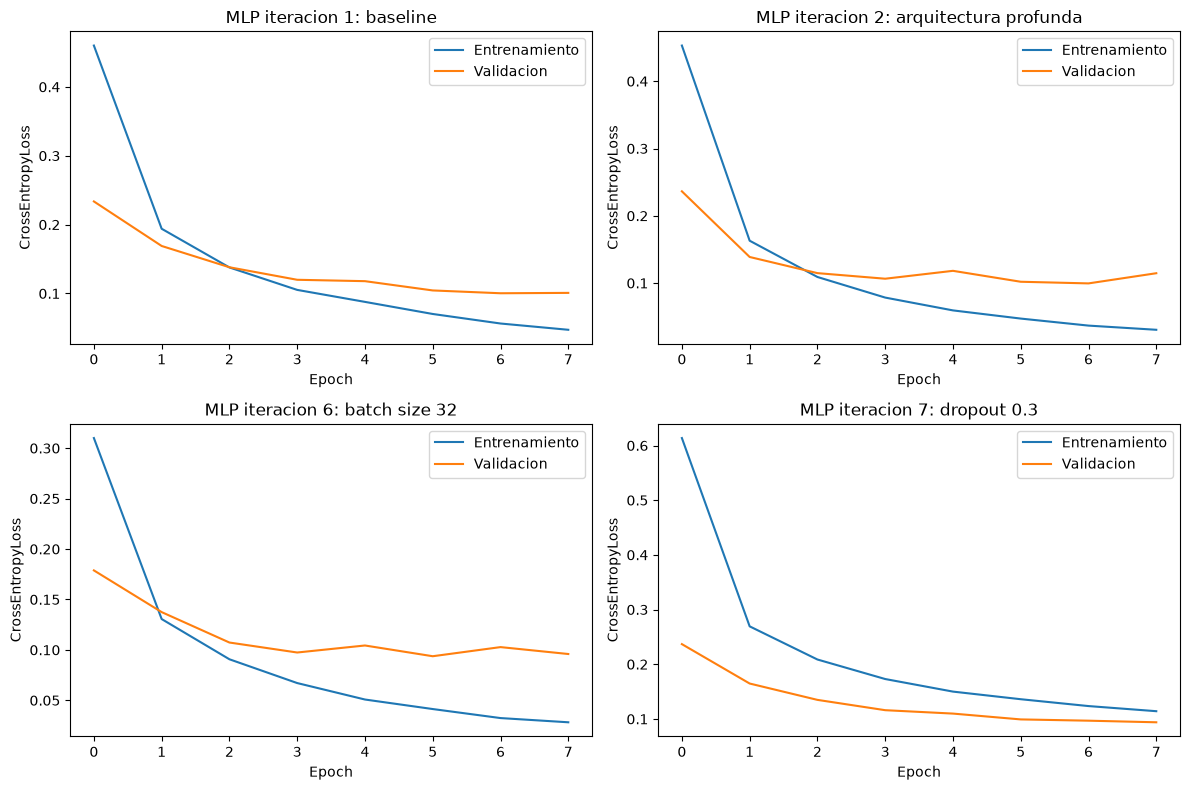

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
selected_mlp = [1, 2, 6, 7]
titles_mlp = {
    1: 'MLP iteracion 1: baseline',
    2: 'MLP iteracion 2: arquitectura profunda',
    6: 'MLP iteracion 6: batch size 32',
    7: 'MLP iteracion 7: dropout 0.3',
}

for ax, iid in zip(axes.flat, selected_mlp):
    h = histories_mlp[iid]
    ax.plot(h['train_loss'], label='Entrenamiento')
    ax.plot(h['val_loss'], label='Validacion')
    ax.set_title(titles_mlp[iid])
    ax.set_xlabel('Epoch')
    ax.set_ylabel('CrossEntropyLoss')
    ax.legend()

plt.tight_layout()
plt.show()

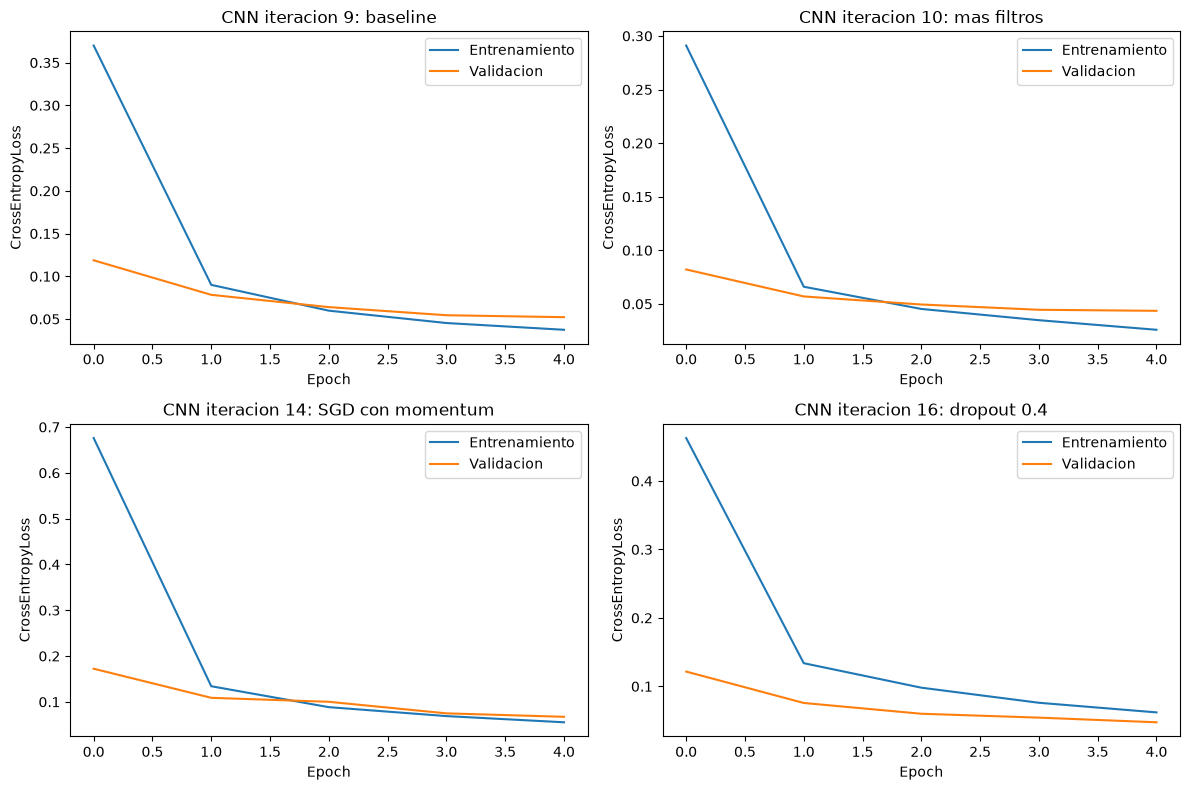

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
selected_cnn = [9, 10, 14, 16]
titles_cnn = {
    9: 'CNN iteracion 9: baseline',
    10: 'CNN iteracion 10: mas filtros',
    14: 'CNN iteracion 14: SGD con momentum',
    16: 'CNN iteracion 16: dropout 0.4',
}

for ax, iid in zip(axes.flat, selected_cnn):
    h = histories_cnn[iid]
    ax.plot(h['train_loss'], label='Entrenamiento')
    ax.plot(h['val_loss'], label='Validacion')
    ax.set_title(titles_cnn[iid])
    ax.set_xlabel('Epoch')
    ax.set_ylabel('CrossEntropyLoss')
    ax.legend()

plt.tight_layout()
plt.show()

En el MLP, el baseline y la arquitectura mas profunda muestran una brecha creciente entre la perdida de entrenamiento y la de validacion conforme avanzan los epochs, una senial de sobreajuste leve asociada a la capacidad del modelo frente al tamanio del dataset. Reducir el batch size a 32 produce una convergencia mas rapida en las primeras epochs por la mayor cantidad de actualizaciones de pesos por epoch. La iteracion con dropout muestra una brecha menor entre ambas curvas, consistente con su efecto regularizador.

En la CNN, el baseline converge mas rapido que el MLP baseline y con una brecha menor entre entrenamiento y validacion, reflejo de que la comparticion de pesos de las capas convolucionales limita el sobreajuste incluso con relativamente pocos parametros. La version con mas filtros reduce tanto la perdida de entrenamiento como la de validacion frente al baseline, manteniendo una brecha igual de pequenia entre ambas curvas, senial de que la capacidad adicional no genero sobreajuste extra en las 5 epochs entrenadas. SGD con momentum parte de una perdida inicial mas alta y converge mas lento en las 5 epochs configuradas. La iteracion con dropout muestra la perdida de entrenamiento mas alta de las cuatro, coherente con el efecto regularizador de apagar neuronas de la capa totalmente conectada.

### 5.4 Comparacion de parametros y accuracy por iteracion

Se relaciona la cantidad de parametros entrenables de cada iteracion, de ambas arquitecturas, con su accuracy sobre el conjunto de validacion.

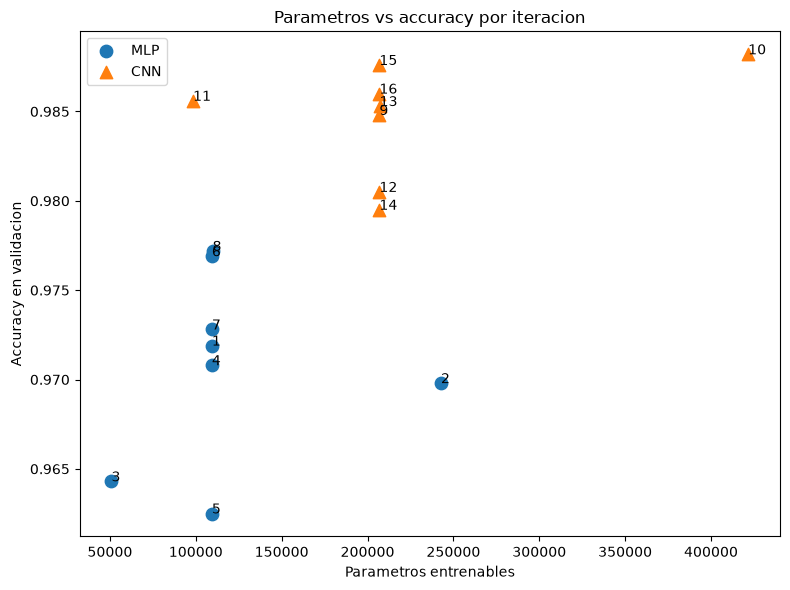

In [18]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(results_mlp_df['Parametros'], results_mlp_df['Accuracy_val'], label='MLP', s=80)
ax.scatter(results_cnn_df['Parametros'], results_cnn_df['Accuracy_val'], label='CNN', s=80, marker='^')

for _, row in results_mlp_df.iterrows():
    ax.annotate(int(row['Iteracion']), (row['Parametros'], row['Accuracy_val']))
for _, row in results_cnn_df.iterrows():
    ax.annotate(int(row['Iteracion']), (row['Parametros'], row['Accuracy_val']))

ax.set_xlabel('Parametros entrenables')
ax.set_ylabel('Accuracy en validacion')
ax.set_title('Parametros vs accuracy por iteracion')
ax.legend()
plt.tight_layout()
plt.show()

### 5.5 Seleccion del mejor modelo de cada arquitectura y evaluacion final sobre test

Se selecciona la mejor configuracion de cada arquitectura segun el F1-score macro de validacion. Cada modelo, ya entrenado durante la busqueda, se evalua una unica vez sobre el conjunto de test, que no participo en ninguna decision anterior de entrenamiento ni de seleccion de hiperparametros.

In [19]:
best_mlp_id = int(results_mlp_df.loc[results_mlp_df['F1_val'].idxmax(), 'Iteracion'])
best_cnn_id = int(results_cnn_df.loc[results_cnn_df['F1_val'].idxmax(), 'Iteracion'])

print('Mejor iteracion MLP segun F1 de validacion:', best_mlp_id)
print('Mejor iteracion CNN segun F1 de validacion:', best_cnn_id)

best_mlp_model = models_mlp[best_mlp_id]
best_cnn_model = models_cnn[best_cnn_id]

test_metrics_mlp = evaluate_model(best_mlp_model, X_test_norm, y_test, cnn=False)
test_metrics_cnn = evaluate_model(best_cnn_model, X_test_norm, y_test, cnn=True)

print('\nMetricas finales del MLP sobre test, evaluado una unica vez:')
print(f"Accuracy:  {test_metrics_mlp['accuracy']:.4f}")
print(f"Precision: {test_metrics_mlp['precision']:.4f}")
print(f"Recall:    {test_metrics_mlp['recall']:.4f}")
print(f"F1-score:  {test_metrics_mlp['f1']:.4f}")

print('\nMetricas finales de la CNN sobre test, evaluado una unica vez:')
print(f"Accuracy:  {test_metrics_cnn['accuracy']:.4f}")
print(f"Precision: {test_metrics_cnn['precision']:.4f}")
print(f"Recall:    {test_metrics_cnn['recall']:.4f}")
print(f"F1-score:  {test_metrics_cnn['f1']:.4f}")

Mejor iteracion MLP segun F1 de validacion: 8
Mejor iteracion CNN segun F1 de validacion: 10



Metricas finales del MLP sobre test, evaluado una unica vez:
Accuracy:  0.9788
Precision: 0.9789
Recall:    0.9786
F1-score:  0.9787

Metricas finales de la CNN sobre test, evaluado una unica vez:
Accuracy:  0.9897
Precision: 0.9898
Recall:    0.9896
F1-score:  0.9896


### 5.6 Matrices de confusion sobre test

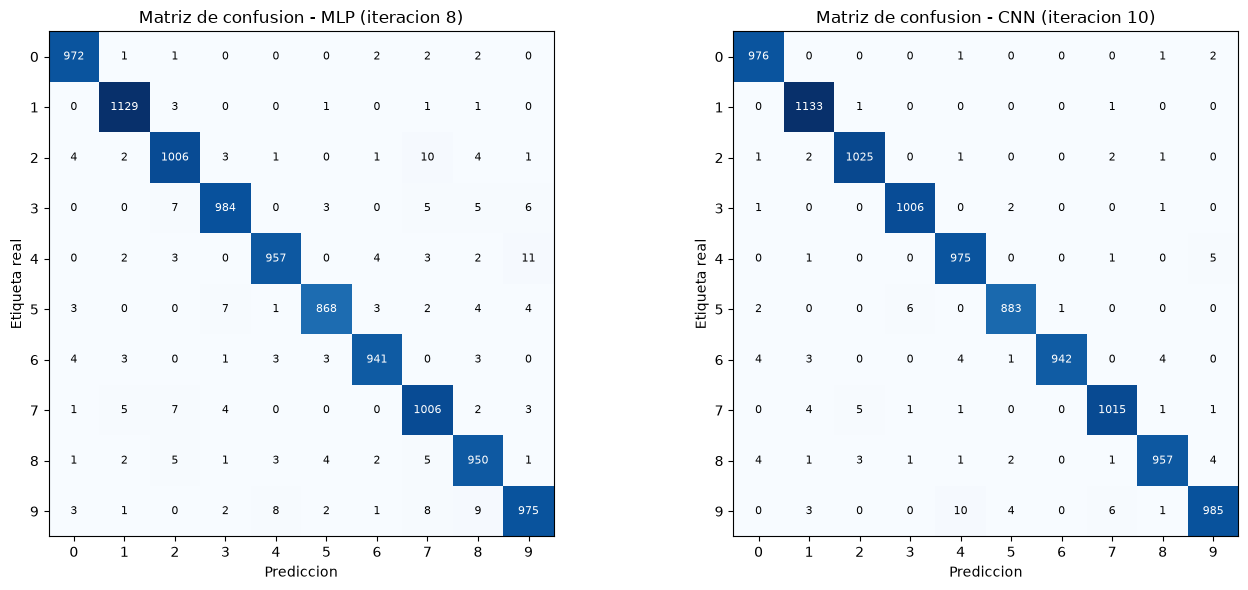

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, cm, titulo in zip(
    axes,
    [test_metrics_mlp['cm'], test_metrics_cnn['cm']],
    [f'MLP (iteracion {best_mlp_id})', f'CNN (iteracion {best_cnn_id})'],
):
    im = ax.imshow(cm, cmap='Blues')
    ax.set_title(f'Matriz de confusion - {titulo}')
    ax.set_xlabel('Prediccion')
    ax.set_ylabel('Etiqueta real')
    ax.set_xticks(range(10))
    ax.set_yticks(range(10))
    for i in range(10):
        for j in range(10):
            ax.text(j, i, cm[i, j], ha='center', va='center',
                     color='white' if cm[i, j] > cm.max() / 2 else 'black', fontsize=8)

plt.tight_layout()
plt.show()

## 6. Comparacion de arquitecturas

La siguiente tabla resume la comparacion directa entre la mejor configuracion del MLP y la mejor configuracion de la CNN, considerando cantidad de parametros entrenables, desempenio sobre test y tiempo de entrenamiento.

In [21]:
comparacion = pd.DataFrame([
    {
        'Arquitectura': 'MLP',
        'Iteracion': best_mlp_id,
        'Parametros': results_mlp_df.loc[results_mlp_df['Iteracion'] == best_mlp_id, 'Parametros'].values[0],
        'Tiempo_entrenamiento_s': results_mlp_df.loc[results_mlp_df['Iteracion'] == best_mlp_id, 'Tiempo_s'].values[0],
        'Accuracy_test': round(test_metrics_mlp['accuracy'], 4),
        'Precision_test': round(test_metrics_mlp['precision'], 4),
        'Recall_test': round(test_metrics_mlp['recall'], 4),
        'F1_test': round(test_metrics_mlp['f1'], 4),
    },
    {
        'Arquitectura': 'CNN',
        'Iteracion': best_cnn_id,
        'Parametros': results_cnn_df.loc[results_cnn_df['Iteracion'] == best_cnn_id, 'Parametros'].values[0],
        'Tiempo_entrenamiento_s': results_cnn_df.loc[results_cnn_df['Iteracion'] == best_cnn_id, 'Tiempo_s'].values[0],
        'Accuracy_test': round(test_metrics_cnn['accuracy'], 4),
        'Precision_test': round(test_metrics_cnn['precision'], 4),
        'Recall_test': round(test_metrics_cnn['recall'], 4),
        'F1_test': round(test_metrics_cnn['f1'], 4),
    },
])
comparacion

,Arquitectura,Iteracion,Parametros,Tiempo_entrenamiento_s,Accuracy_test,Precision_test,Recall_test,F1_test
0,MLP,8,109770,6.6,0.9788,0.9789,0.9786,0.9787
1,CNN,10,421642,33.0,0.9897,0.9898,0.9896,0.9896
